In [1]:
%%capture

import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

from astroquery.sdss import SDSS

In [2]:
sql = '''SELECT 
    (g.oiii_5007_flux / g.h_beta_flux) AS oiii_hbeta_ratio,
    (g.nii_6584_flux / g.h_alpha_flux) AS nii_halpha_ratio
FROM SpecObj AS s
JOIN galSpecLine AS g ON s.specobjid = g.specobjid
WHERE s.class = 'GALAXY' 
  AND s.snmedian_g > 10
  AND g.oiii_5007_eqw < -0.1
  AND g.nii_6584_eqw < -0.1
  AND g.h_beta_eqw < -0.1
  AND g.h_alpha_eqw < -0.1
  AND g.oiii_5007_flux > 5
  AND g.nii_6584_flux > 5
  AND g.h_beta_flux > 5
  AND g.h_alpha_flux > 5
  AND g.oiii_5007_flux > 3 * g.oiii_5007_flux_err
  AND g.nii_6584_flux > 3 * g.nii_6584_flux_err
  AND g.h_beta_flux > 3 * g.h_beta_flux_err
  AND g.h_alpha_flux > 3 * g.h_alpha_flux_err
  AND (2.355 * g.sigma_forbidden) < 500
  AND (2.355 * g.sigma_balmer) < 500'''

table = SDSS.query_sql(sql)

df = table.to_pandas()

print(f"found {len(df)} objects")

found 153231 objects


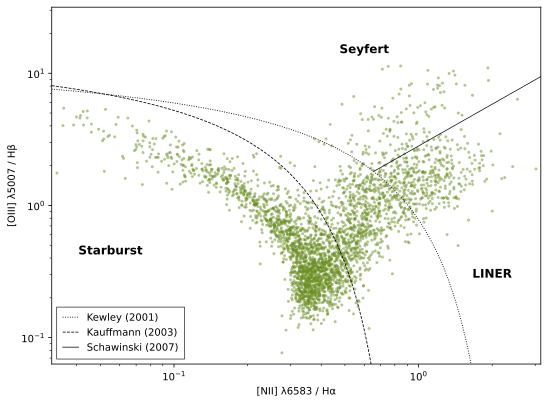

In [3]:
%config InlineBackend.figure_formats = ['svg']

x = np.logspace(-1.5, 0.5, 400)

y_kewl = 10**(0.61 / (np.log10(x) - 0.47) + 1.19)
y_kewl = y_kewl[x < 10**(0.47)]
x_kewl = x[x < 10**(0.47)]

y_kauf = 10**(0.61 / (np.log10(x) - 0.05) + 1.3)
y_kauf = y_kauf[x < 10**(0.05)]
x_kauf = x[x < 10**(0.05)]

y_scha = 10**(1.05 * np.log10(x) + 0.45)
x_scha = x[np.argmin(np.abs(y_scha[:len(y_kewl)] - y_kewl)):]
y_scha = y_scha[np.argmin(np.abs(y_scha[:len(y_kewl)] - y_kewl)):]

fig, ax = plt.subplots(1, 1, figsize=[7.5, 5.5], constrained_layout=True)

sparse = 50

ax.plot(df['nii_halpha_ratio'][::sparse], df['oiii_hbeta_ratio'][::sparse],
        ls='none', marker='o', mec='none', mfc='olivedrab', ms=3, alpha=0.5)

ax.plot(x_kewl, y_kewl, 'k:', lw=0.9, label='Kewley (2001)')
ax.plot(x_kauf, y_kauf, 'k--', lw=0.8, label='Kauffmann (2003)')
ax.plot(x_scha, y_scha, 'k-', lw=0.7, label='Schawinski (2007)')

ax.text(2, 0.3, 'LINER', va='center', ha='center', size='large', weight='bold')
ax.text(0.6, 15, 'Seyfert', va='center', ha='center', size='large', weight='bold')
ax.text(0.055, 0.45, 'Starburst', va='center', ha='center', size='large', weight='bold')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(10**(-1.5), 10**(0.5))
ax.set_ylim(10**(-1.2), 10**(1.5))

ax.set_xlabel('[NII] λ6583 / Hα')
ax.set_ylabel('[OIII] λ5007 / Hβ')

leg = ax.legend(frameon=True, fancybox=False, loc='lower left', edgecolor='black', framealpha=1, handlelength=1.6, borderpad=0.6)
leg.get_frame().set_linewidth(0.6)

fig.savefig('assets/bpt_diagram.pdf')
fig.savefig('assets/bpt_diagram.png', dpi=600)

plt.show()
plt.close()

***Short Caption:*** SDSS galaxies in the classical BPT diagram. Depicted is the theoretical delimiter by *Kewley et al. (2001)* as well as the empirical line by *Kauffmann et al. (2003)* to distinguish predominantly starforming galaxies from AGN. Additionally, the *Schawinski et al. (2007)* boundary sorts AGN into efficiently accreting Seyfert and inefficient LINER subtypes. Refer to [this](https://github.com/fritzali/notes/blob/main/MASS/Active/homework/0/bpt.ipynb) notebook for more details on the figure.

***Long Caption:*** Select galaxy objects from the Sloan Digital Sky Survey (SDSS) catalog shown in the well known BPT diagram named after its introduction in a seminal paper by *Baldwin, Phillips, and Terlevich (1981)*. It plots the intensity of the [OIII] λ5007 forbidden transition relative to that of the Hβ line versus the ratio of [NII] λ6583 to Hα on logarithmic axes. Using this to infer ionization states and abundances of the emitting medium enables us to reconstruct the origin of the dominant radiation in the galactic host, which has led to various approaches for the classification of these objects. Here, we include the theoretical boundary described by *Kewley et al. (2001)* between starburst and active galaxies, as well as the empirical delimiter by *Kauffmann et al. (2003)* based on SDSS observations. Furthermore, the Active Galactic Nucleus (AGN) class is split according to *Schawinski et al. (2007)* into Seyferts characterized by high accretion rates, and Low Ionization Nuclear Emissionline Region (LINER) galaxies that are thought to be accreting matter inefficiently. Refer to [this](https://github.com/fritzali/notes/blob/main/MASS/Active/homework/0/bpt.ipynb) notebook for more details on data acquisition and to modify the figure.

***Download:*** [[PDF]](assets/bpt_diagram.pdf) [[PNG]](assets/bpt_diagram.png)

<br>

***Paper:*** [Baldwin J. A., Phillips M. M., Terlevich R., 1981, PASP, 93, 5](https://ui.adsabs.harvard.edu/abs/1981PASP...93....5B)

<br>

#### [Kewley L. J. et al. 2001, ApJ, 556, 121](https://ui.adsabs.harvard.edu/abs/2001ApJ...556..121K)

$\displaystyle{\text{(5)}\qquad\log(\symup{[OIII]}/\symup{Hβ}) = \frac{0.61}{\log(\symup{[NII]}/\symup{Hα}) − 0.47} + 1.19}$

#### [Kauffmann G. et al. 2003, MNRAS, 346, 1055](https://ui.adsabs.harvard.edu/abs/2003MNRAS.346.1055K)

$\displaystyle{\text{(1)}\qquad\log(\symup{[OIII]}/\symup{Hβ}) = \frac{0.61}{\log(\symup{[NII]}/\symup{Hα}) - 0.05} + 1.3}$

#### [Schawinski K. et al. 2007, MNRAS, 382, 1415](https://ui.adsabs.harvard.edu/abs/2007MNRAS.382.1415S)

$\displaystyle{\text{(1)}\qquad\log(\symup{[O III]}/\symup{Hβ}) = 1.05 \log(\symup{[N II]}/\symup{Hα}) + 0.45}$